# The Multi-Needle Problem, Part 2: Where Does Agentic Reasoning Break Down?

**Mehrab Modi** | May 2026 | [github.com/mehrabmodi1/agentic-retrieval](https://github.com/mehrabmodi1/agentic-retrieval)

In an earlier article, *The Multi-Needle Problem*, I showed that Claude Code, arguably one of today's best coding agents, reliably fails at *simultaneous retrieval and reasoning over n=16 items*. This failure depended on the number of facts to retrieve, hold in memory and reason across. The headline result: even Opus 4.7 at maximum effort collapses on multi-reasoning at n=16, while every configuration handles n=2 perfectly. It is not a model problem and not a test-time-compute problem — it looks like a structural limit of how today's agents hold information in working memory.

That finding rested on a coarse sampling of the n-items axis: only n=2 and n=16. Two endpoints, with everything between them invisible. This follow-up traces the curve. Holding everything else constant — effort=max, 40k token python-repo corpus — I densely sampled the n-items axis at n ∈ {4, 6, 8, 10, 12, 14, 16}. Three model configurations: Sonnet 4.6, Opus 4.6, Opus 4.7, all at effort=max. The result, plotted in Figure 0.5, sharpens the original picture into something more actionable: a steep cliff between n=10 and n=12, after which all three configurations drop towards the floor.

Next, I designed tasks that dissect the original multi-reasoning problem, where performance fell off like a cliff in figure 0.5. Three findings come out of pulling that cliff apart. First, the cliff is sharp — a relatively sudden transition centred between n=8 and n=12, not a gradual degradation. Second, no cognitive primitive reproduces it on its own. The dissection separates retrieval from reasoning, then ramps the reasoning side through three cumulative levels, each layering one new primitive on the previous (Levels 1, 2 and 3). Pure retrieval scales cleanly from n = 2 to 16 items; the simultaneous-reasoning L1 → L2 → L3 ramp degrades gracefully but never cliffs. The cliff lives only in the *interaction* between retrieval and reasoning — holding partial findings while continuing to search for more, and reasoning across them. Finally, Sonnet 4.6 tracks Opus 4.7 closely across the whole sweep; model size barely moves the cliff. How do coding agents get better then? Perhaps the answer is in what we saw in the dissection. Models and harnesses getting better at recognising their limits, and breaking the task down by handing off to a file-write and a separate agent-call.

In [1]:
BATCH_NAME = "full-sweep__20260408T130426"
WORKSPACE_DIR = "../workspace"

In [2]:
from pathlib import Path
from agent_retrieval.analysis.loader import load_batch_results
df = load_batch_results(BATCH_NAME, Path(WORKSPACE_DIR))

## Figure 0: Model and Effort Comparison

Recapitulating the headline comparison from the previous article. Six agent configurations — Sonnet 4.6, Opus 4.6, Opus 4.7, each at effort=low and effort=max — across three task types: **single-needle** (find one fact), **multi-chain** (follow cross-references), and **multi-reasoning** (synthesise across multiple scattered facts). The grid splits by corpus size (40k vs 800k tokens) and number of items (n=2 vs n=16). Three runs per condition; each dot is one run.


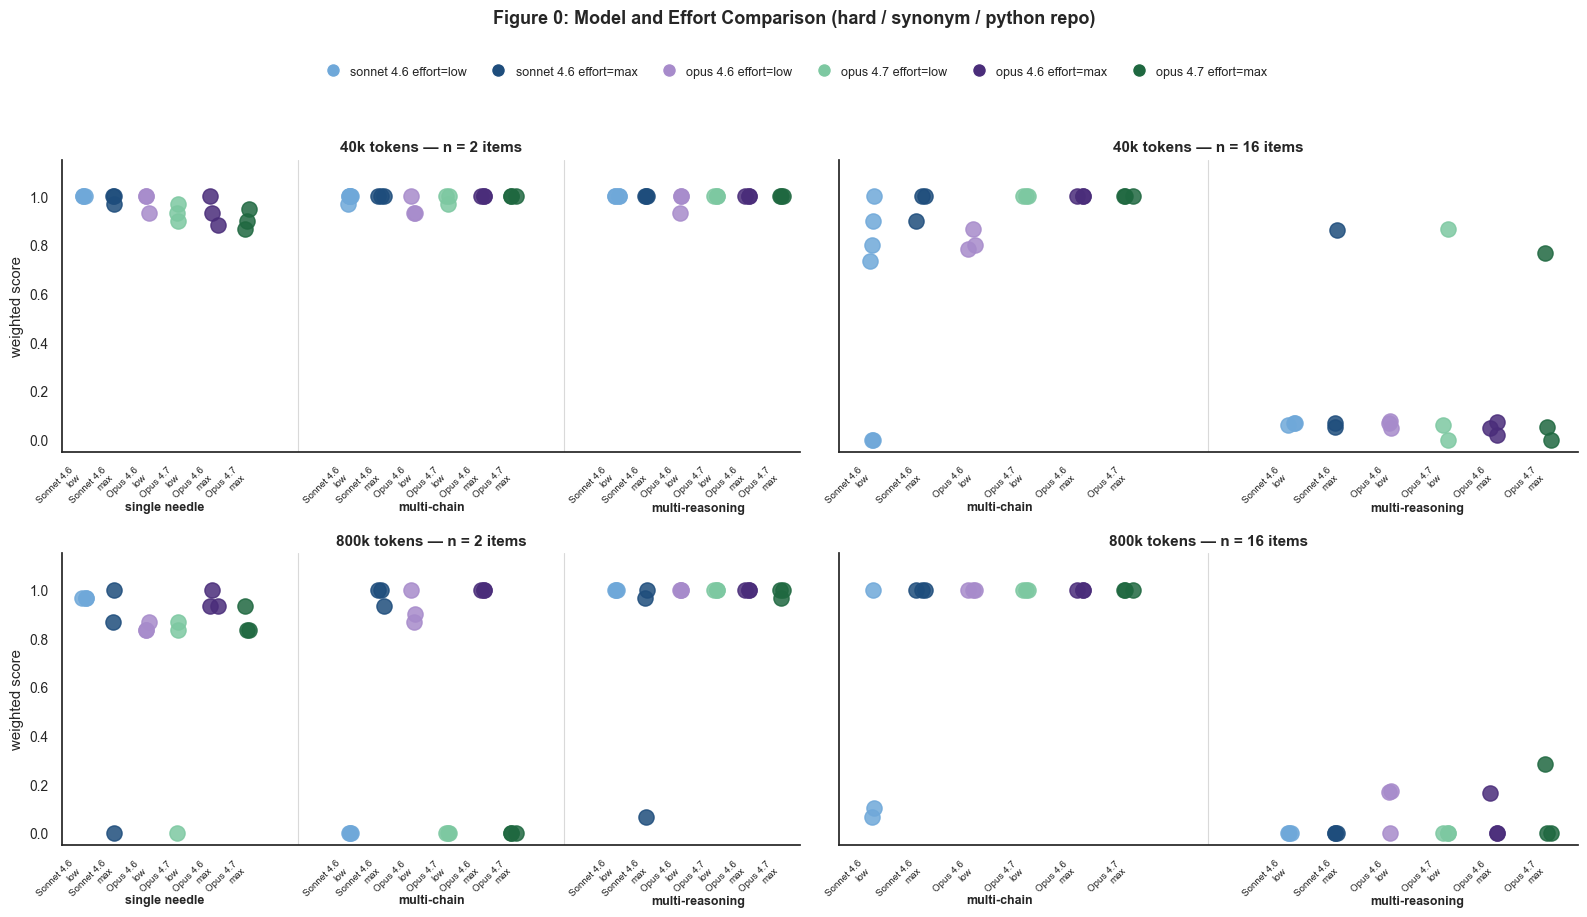

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import yaml as _yaml

sns.set_theme(style="white", font_scale=0.9)

# --- Figure 0: Model and Effort Comparison ---

COMPARISON_BATCHES = {
    "sonnet 4.6\neffort=low": "full-sweep__20260408T130426",
    "sonnet 4.6\neffort=max": "hard-synonym-subset_sonnet-4-6_effort-max__20260413T103017",
    "opus 4.6\neffort=low": "hard-synonym-subset_opus-4-6_effort-low__20260413T112314",
    "opus 4.7\neffort=low": "hard-synonym-subset_opus-4-7_effort-low__20260418T055310",
    "opus 4.6\neffort=max": "hard-synonym-subset_opus-4-6_effort-max__20260419T140322",
    "opus 4.7\neffort=max": "hard-synonym-subset_opus-4-7_effort-max__20260419T133904",
}

# Colour by model (hue): sonnet=blue, opus 4.6=purple, opus 4.7=green.
# Effort by shade: low=lighter, max=darker.
CONFIG_COLORS = {
    "sonnet 4.6\neffort=low": "#6FA8D9",   # light blue
    "sonnet 4.6\neffort=max": "#1E4D7C",   # dark blue
    "opus 4.6\neffort=low":   "#A78BCB",   # light purple
    "opus 4.6\neffort=max":   "#4A2D7A",   # dark purple
    "opus 4.7\neffort=low":   "#7DC8A1",   # light green
    "opus 4.7\neffort=max":   "#1F6840",   # dark green
}

CONFIG_SHORT = {
    "sonnet 4.6\neffort=low": "Sonnet 4.6\nlow",
    "sonnet 4.6\neffort=max": "Sonnet 4.6\nmax",
    "opus 4.6\neffort=low": "Opus 4.6\nlow",
    "opus 4.7\neffort=low": "Opus 4.7\nlow",
    "opus 4.6\neffort=max": "Opus 4.6\nmax",
    "opus 4.7\neffort=max": "Opus 4.7\nmax",
}

CORPUS_SIZES = [40_000, 800_000]
CORPUS_LABELS = {40_000: "40k tokens", 800_000: "800k tokens"}

# Collect all individual scores into a tidy dataframe
rows = []
for config_label, batch_name in COMPARISON_BATCHES.items():
    jdir = Path(f"../workspace/judge/judgements/{batch_name}")
    for v in sorted(jdir.rglob("*.yaml")):
        data = _yaml.safe_load(v.read_text())
        pid = data["parametrisation_id"]

        if "python_repo" not in pid or "hard" not in pid or "synonym" not in pid:
            continue

        corpus_size = None
        if "40k" in pid:
            corpus_size = 40_000
        elif "800k" in pid:
            corpus_size = 800_000
        else:
            continue

        et = pid.split("__")[0]
        n_items = None
        if et in ("multi_chain", "multi_reasoning"):
            for part in pid.split("__"):
                if part.startswith("n") and part[1:].isdigit():
                    n_items = int(part[1:])
            if n_items not in (2, 16):
                continue

        rows.append({
            "config": config_label,
            "experiment_type": et,
            "n_items": n_items,
            "corpus_size": corpus_size,
            "score": data["weighted_score"],
        })

fig0_df = pd.DataFrame(rows)

exp_label_map = {
    "single_needle":   "single needle",
    "multi_chain":     "multi-chain",
    "multi_reasoning": "multi-reasoning",
}
config_labels = list(COMPARISON_BATCHES.keys())
n_configs = len(config_labels)
group_spacing = 0.16   # offset between configs within a group
group_gap = 1.3        # distance between experiment-type groups
dot_size = 120
jitter_width = 0.04

fig0, axes0 = plt.subplots(2, 2, figsize=(16, 9), sharey=True)

for row_idx, corpus_size in enumerate(CORPUS_SIZES):
    for col_idx, n_val in enumerate([2, 16]):
        ax = axes0[row_idx, col_idx]
        panel_exp_types = (
            ["single_needle", "multi_chain", "multi_reasoning"] if col_idx == 0
            else ["multi_chain", "multi_reasoning"]
        )
        n_groups = len(panel_exp_types)

        sub = fig0_df[fig0_df["corpus_size"] == corpus_size]
        if col_idx == 0:
            sub = sub[(sub["n_items"].isna()) | (sub["n_items"] == n_val)]
        else:
            sub = sub[sub["n_items"] == n_val]
        sub = sub[sub["experiment_type"].isin(panel_exp_types)]

        # Compute x positions: each group centred at group_idx * group_gap
        # configs within group spread symmetrically
        group_centers = {et: i * group_gap for i, et in enumerate(panel_exp_types)}
        config_offsets = {
            cfg: (ci - (n_configs - 1) / 2) * group_spacing
            for ci, cfg in enumerate(config_labels)
        }

        tick_positions = []
        tick_labels = []

        for ci, config_label in enumerate(config_labels):
            cfg_sub = sub[sub["config"] == config_label]
            np.random.seed(ci)
            for _, row_data in cfg_sub.iterrows():
                et = row_data["experiment_type"]
                xpos = group_centers[et] + config_offsets[config_label]
                jitter = np.random.uniform(-jitter_width / 2, jitter_width / 2)
                ax.scatter(
                    xpos + jitter, row_data["score"],
                    color=CONFIG_COLORS[config_label],
                    s=dot_size, alpha=0.85, zorder=3,
                )

        # x-ticks: one per config per group, labelled with short config name
        for et in panel_exp_types:
            gc = group_centers[et]
            for ci, cfg in enumerate(config_labels):
                xpos = gc + config_offsets[cfg]
                tick_positions.append(xpos)
                tick_labels.append(CONFIG_SHORT[cfg])

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha="right")

        # Group labels (experiment type) above the tick area
        for et in panel_exp_types:
            gc = group_centers[et]
            ax.text(gc, -0.17, exp_label_map[et], ha="center", va="top",
                    fontsize=9, fontweight="bold", transform=ax.get_xaxis_transform())

        # Vertical separators between groups
        for i in range(1, n_groups):
            sep = (group_centers[panel_exp_types[i-1]] + group_centers[panel_exp_types[i]]) / 2
            ax.axvline(sep, color="0.85", linewidth=0.8, zorder=0)

        ax.set_xlim(
            group_centers[panel_exp_types[0]] - 0.5,
            group_centers[panel_exp_types[-1]] + 0.5,
        )
        ax.set_ylim(-0.05, 1.15)
        ax.set_title(f"{CORPUS_LABELS[corpus_size]} — n = {n_val} items", fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("weighted score" if col_idx == 0 else "")
        sns.despine(ax=ax)

# Legend (colour = config)
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CONFIG_COLORS[cfg],
           markersize=10, label=cfg.replace("\n", " "))
    for cfg in config_labels
]
fig0.legend(
    handles=handles, ncol=len(config_labels),
    loc="upper center", bbox_to_anchor=(0.5, 0.97),
    fontsize=9, frameon=False, columnspacing=1.5, handletextpad=0.4,
)

fig0.suptitle("Figure 0: Model and Effort Comparison (hard / synonym / python repo)",
              fontsize=13, fontweight="bold", y=1.02)
fig0.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


At n=2, most configurations succeed in both corpus sizes, with two effort=low configurations collapsing on multi-chain at 800k via hallucination. At n=16, multi-reasoning fails across every configuration in both corpus sizes — the core finding of the previous article. Larger corpus size amplifies the failure but does not cause it; the wall is consistent across model scale, effort budget, and corpus size. The next section densifies the n-items axis to locate where the wall actually lives.


## Figure 0.5: The n-items cliff, isolated

Figure 0 sampled only the endpoints (n=2 and n=16) and showed that multi-reasoning collapses by the right-hand column. To trace where the collapse actually happens, this figure densifies the n-items axis and isolates it from confounding variables. Three effort=max configurations are compared — Sonnet 4.6, Opus 4.6, Opus 4.7 — on a fixed slice: multi-reasoning, python repo, 40k corpus, easy discriminability, synonym references. Each dot is one individual run (3 per condition).

Compared to Figure 0, this view varies only `n_items` (4, 6, 8, 10, 12, 14, 16) — corpus size, content profile, discriminability, reference clarity, and effort budget are all held constant. 

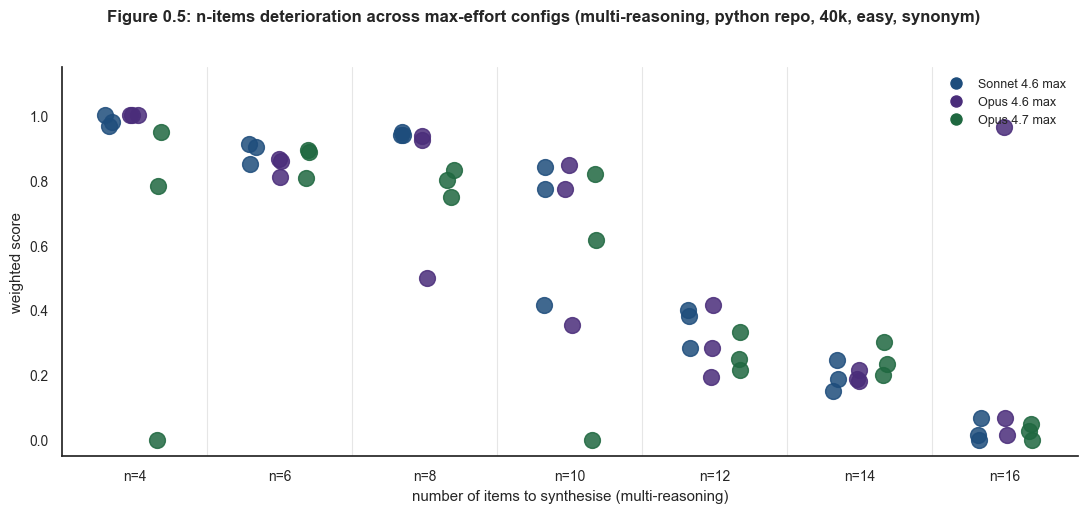

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import yaml as _yaml

sns.set_theme(style="white", font_scale=0.9)

# --- Figure 0.5: dense n-items sweep across three effort=max configs ---
# multi_reasoning, python_repo, 40k, easy, synonym; n_items in [4..16].

DENSE_BATCHES = {
    "sonnet 4.6\neffort=max": "dense-n-multi-reasoning_sonnet-4-6_effort-max__20260425T084231",
    "opus 4.6\neffort=max":   "dense-n-multi-reasoning_opus-4-6_effort-max__20260425T085358",
    "opus 4.7\neffort=max":   "dense-n-multi-reasoning_opus-4-7_effort-max__20260425T090337",
}

# Colours match Figure 0's max-effort shades: sonnet=dark blue, opus 4.6=dark purple, opus 4.7=dark green.
DENSE_COLORS = {
    "sonnet 4.6\neffort=max": "#1E4D7C",
    "opus 4.6\neffort=max":   "#4A2D7A",
    "opus 4.7\neffort=max":   "#1F6840",
}

DENSE_SHORT = {
    "sonnet 4.6\neffort=max": "Sonnet 4.6 max",
    "opus 4.6\neffort=max":   "Opus 4.6 max",
    "opus 4.7\neffort=max":   "Opus 4.7 max",
}

N_ITEMS_DENSE = [4, 6, 8, 10, 12, 14, 16]

rows = []
for config_label, batch_name in DENSE_BATCHES.items():
    jdir = Path(f"../workspace/judge/judgements/{batch_name}")
    for v in sorted(jdir.rglob("*.yaml")):
        data = _yaml.safe_load(v.read_text())
        pid = data["parametrisation_id"]
        if "multi_reasoning" not in pid: continue
        if "python_repo" not in pid: continue
        if "40k" not in pid: continue
        if "easy" not in pid: continue
        if "synonym" not in pid: continue
        n_items = None
        for part in pid.split("__"):
            if part.startswith("n") and part[1:].isdigit():
                n_items = int(part[1:])
        if n_items not in N_ITEMS_DENSE: continue
        rows.append({
            "config": config_label,
            "n_items": n_items,
            "score": data["weighted_score"],
        })

dense_df = pd.DataFrame(rows)

config_labels = list(DENSE_BATCHES.keys())
n_configs = len(config_labels)
group_spacing = 0.18
group_gap = 1.0
dot_size = 130
jitter_width = 0.06

fig05_new, ax = plt.subplots(figsize=(11, 5))

group_centers = {n: i * group_gap for i, n in enumerate(N_ITEMS_DENSE)}
config_offsets = {
    cfg: (ci - (n_configs - 1) / 2) * group_spacing
    for ci, cfg in enumerate(config_labels)
}

for ci, config_label in enumerate(config_labels):
    cfg_sub = dense_df[dense_df["config"] == config_label]
    np.random.seed(ci)
    for _, row_data in cfg_sub.iterrows():
        n = row_data["n_items"]
        xpos = group_centers[n] + config_offsets[config_label]
        jitter = np.random.uniform(-jitter_width / 2, jitter_width / 2)
        ax.scatter(
            xpos + jitter, row_data["score"],
            color=DENSE_COLORS[config_label],
            s=dot_size, alpha=0.85, zorder=3,
        )

ax.set_xticks([group_centers[n] for n in N_ITEMS_DENSE])
ax.set_xticklabels([f"n={n}" for n in N_ITEMS_DENSE], fontsize=10)

for i in range(1, len(N_ITEMS_DENSE)):
    sep = (group_centers[N_ITEMS_DENSE[i-1]] + group_centers[N_ITEMS_DENSE[i]]) / 2
    ax.axvline(sep, color="0.9", linewidth=0.8, zorder=0)

ax.set_xlim(group_centers[N_ITEMS_DENSE[0]] - 0.5, group_centers[N_ITEMS_DENSE[-1]] + 0.5)
ax.set_ylim(-0.05, 1.15)
ax.set_ylabel("weighted score")
ax.set_xlabel("number of items to synthesise (multi-reasoning)")
sns.despine(ax=ax)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=DENSE_COLORS[cfg],
           markersize=10, label=DENSE_SHORT[cfg])
    for cfg in config_labels
]
ax.legend(handles=handles, loc="upper right", fontsize=9, frameon=False)

fig05_new.suptitle(
    "Figure 0.5: n-items deterioration across max-effort configs (multi-reasoning, python repo, 40k, easy, synonym)",
    fontsize=12, fontweight="bold", y=1.02,
)
fig05_new.tight_layout()
plt.show()


At n ∈ {4, 6, 8} all three configurations cluster at or above ~0.79, with one Opus 4.7 outlier at n=4 (~0.58). Between n=8 and n=12 every configuration drops by roughly half. At n=14 the three configurations sit between ~0.19 and ~0.25. At n=16, Sonnet 4.6 and Opus 4.7 fall further to ~0.03; Opus 4.6 holds at ~0.35.


## What the dense sweep shows

The picture is almost identical across the three model-configurations. From n=4 through n=8, all three agents handle the task reliably — weighted scores stay at or above ~0.79. The only outlier is a low Opus 4.7 cluster at n=4 that recovers immediately at n=6 (likely noise on a three-run sample). The "easy" half of the curve is flat.

Then the cliff. Between n=8 and n=12 every configuration drops by roughly half. By n=14 all three sit between 0.19 and 0.25; at n=16 Sonnet 4.6 and Opus 4.7 drop the rest of the way, to 0.03 — essentially full collapse — while Opus 4.6 holds at 0.35.

That sharpens the original finding considerably. The Figure 0 wall in the n=2 vs n=16 comparison is not a slow, smooth degradation — it is a relatively sharp transition n = 10 to n = 14. For a system designer, the practically actionable number is now in plain sight: tasks that demand simultaneous retrieval and reasoning across more than ~10 retrieved facts will fail current agents regardless of which one is used.

The natural next question is *why* the cliff sits where it does. Is it a working-memory limit — too many items to hold simultaneously while still searching for more? Simultaneous reasoning across many pieces of information? The rest of this article tries to dissect the cliff and shows that its actually both retrieval and reasoning that case the breakdown.


## Separating retrieval from reasoning

The multi-reasoning task bundles two cognitive operations into one. The agent has to (1) **retrieve** the N relevant items scattered through the corpus, and (2) **reason** across all N, holding each in working memory long enough to synthesise an answer that depends on every one. The cliff in Figure 0.5 could be coming from either operation, or from their interaction. If retrieval on its own is fine at n=16 but reasoning is not, the bottleneck is reasoning. If reasoning on its own is fine but retrieval falls apart at high n, the bottleneck is retrieval. If both work in isolation but their combination fails, the cliff lives in the *interaction* — the agent cannot juggle "still searching" and "already found" simultaneously once the load gets high enough.

To pull the two apart, I built two new experiment families. Each holds one of the two operations trivial and stresses only the other:

- **Multi-retrieval** — find N items hidden in a corpus and report each verbatim. Retention only; no reasoning required.
- **Pure reasoning** — the N items are inlined directly in the prompt; there is no corpus and nothing to search. Reasoning only; no retrieval required.

Within pure reasoning, cognitive complexity is further ramped in three controlled steps (Level1 → Level2 → Level3), described in detail in the task design section below.

If neither pure retrieval nor pure reasoning fails on its own at n=16, the multi-reasoning cliff is an artefact of having to do both at the same time — the working-memory cost of holding partial findings while still searching for more.


## Figure 1: Dissecting the multi-reasoning task

The multi-reasoning task bundles two cognitive operations: (1) **retrieve** N relevant items scattered through the corpus and (2) **reason** across N items specified in the question (no retrieval)— classify each as a lower or upper bound, then take the tightest of each. To localise where cliff in figure 0.5 comes from, I built four experiments. Each holds one operation trivial and stresses only the other, then progressively layers in cognitive primitives:

- **Multi-retrieval** — find N items in an 800k-token corpus and report each verbatim. Retention only; no reasoning.
- **Pure reasoning, Level1 — classify + sort** — N facts inlined directly in the prompt; no corpus, no retrieval. Classify each as a lower or upper bound, take the tightest of each.
- **Pure reasoning, Level2 — Level1 + mixed units** — same N facts, but rewritten into mixed surface forms (canonical, alt-units, or offsets from a named reference). The agent must normalise before reasoning.
- **Pure reasoning, Level3 — Level2 + conditional gating** — each L2 item gains a precondition gate ("if X, then..."); a small world-state block at the prompt top fixes which gates are live. The agent must filter dead facts before reasoning.

Same three effort=max configurations as Figure 0.5; same n_items grid (2/4/8/12/16); 3 runs per condition. Rows split python_repo (top) and noir_fiction (bottom). Each dot is one individual run.

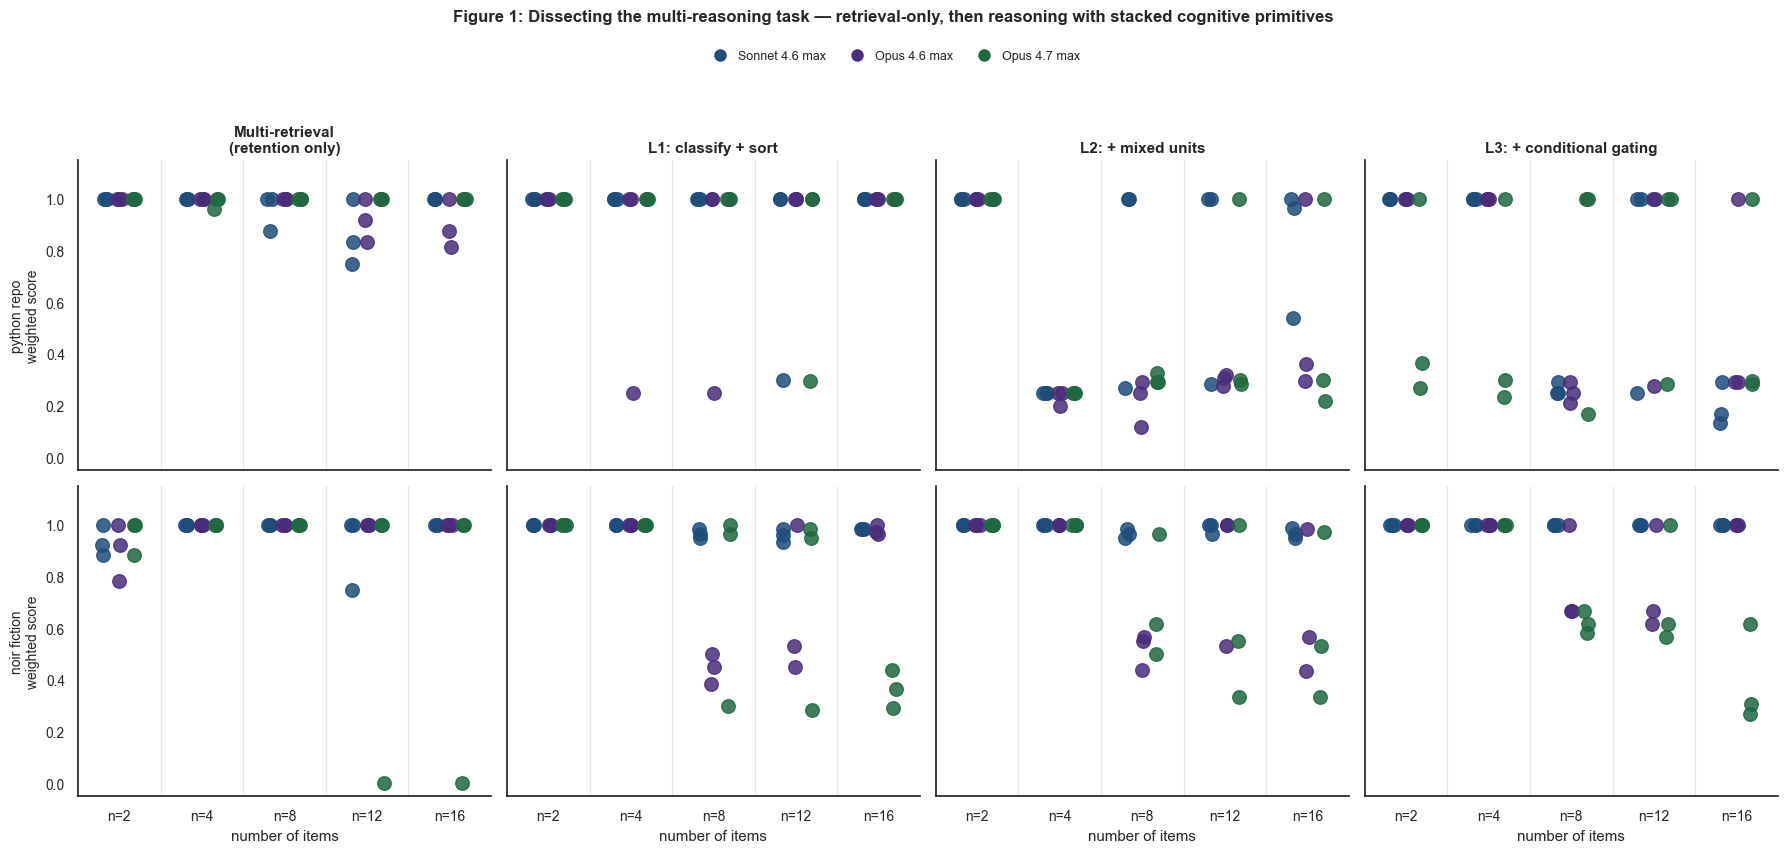

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import yaml as _yaml

sns.set_theme(style="white", font_scale=0.9)

# --- Figure 1: full dissection — multi-retrieval + cognitive ladder L1/L2/L3 ---

DISSECTION_BATCHES = {
    "sonnet 4.6\neffort=max": {
        "multi_retrieval":    "multi-reasoning-dissection_sonnet-4-6_effort-max__20260502T115755",
        "pure_reasoning":     "multi-reasoning-dissection_sonnet-4-6_effort-max__20260502T115755",
        "pure_reasoning_l2":  "cognitive-ladder_sonnet-4-6_effort-max__20260503T112737",
        "pure_reasoning_l3":  "cognitive-ladder_sonnet-4-6_effort-max__20260503T112737",
    },
    "opus 4.6\neffort=max": {
        "multi_retrieval":    "multi-reasoning-dissection_opus-4-6_effort-max__20260502T104815",
        "pure_reasoning":     "multi-reasoning-dissection_opus-4-6_effort-max__20260502T104815",
        "pure_reasoning_l2":  "cognitive-ladder_opus-4-6_effort-max__20260503T103356",
        "pure_reasoning_l3":  "cognitive-ladder_opus-4-6_effort-max__20260503T103356",
    },
    "opus 4.7\neffort=max": {
        "multi_retrieval":    "multi-reasoning-dissection_opus-4-7_effort-max__20260502T095101",
        "pure_reasoning":     "multi-reasoning-dissection_opus-4-7_effort-max__20260502T095101",
        "pure_reasoning_l2":  "cognitive-ladder_opus-4-7_effort-max__20260503T101506",
        "pure_reasoning_l3":  "cognitive-ladder_opus-4-7_effort-max__20260503T101506",
    },
}

DENSE_COLORS = {
    "sonnet 4.6\neffort=max": "#1E4D7C",
    "opus 4.6\neffort=max":   "#4A2D7A",
    "opus 4.7\neffort=max":   "#1F6840",
}

DENSE_SHORT = {
    "sonnet 4.6\neffort=max": "Sonnet 4.6 max",
    "opus 4.6\neffort=max":   "Opus 4.6 max",
    "opus 4.7\neffort=max":   "Opus 4.7 max",
}

PROFILES = ["python_repo", "noir_fiction"]
PROFILE_LABELS = {"python_repo": "python repo", "noir_fiction": "noir fiction"}

LEVELS = ["multi_retrieval", "pure_reasoning", "pure_reasoning_l2", "pure_reasoning_l3"]
LEVEL_LABELS = {
    "multi_retrieval":    "Multi-retrieval\n(retention only)",
    "pure_reasoning":     "L1: classify + sort",
    "pure_reasoning_l2":  "L2: + mixed units",
    "pure_reasoning_l3":  "L3: + conditional gating",
}

N_ITEMS = [2, 4, 8, 12, 16]

rows = []
for cfg, level_to_batch in DISSECTION_BATCHES.items():
    for level, batch in level_to_batch.items():
        for v in sorted(Path(f"../workspace/judge/judgements/{batch}").rglob("*.yaml")):
            d = _yaml.safe_load(v.read_text())
            pid = d["parametrisation_id"]
            et = pid.split("__")[0]
            if et != level:
                continue
            profile = pid.split("__")[1]
            if profile not in PROFILES:
                continue
            n = next((int(p[1:]) for p in pid.split("__") if p.startswith("n") and p[1:].isdigit()), None)
            if n not in N_ITEMS:
                continue
            rows.append({
                "config": cfg, "level": level, "profile": profile,
                "n_items": n, "score": d["weighted_score"],
            })

dis_df = pd.DataFrame(rows)

config_labels = list(DISSECTION_BATCHES.keys())
n_configs = len(config_labels)
group_spacing = 0.18
group_gap = 1.0
dot_size = 95
jitter_width = 0.06

fig1, axes1 = plt.subplots(2, 4, figsize=(18, 8.5), sharey=True, sharex=True)

group_centers = {n: i * group_gap for i, n in enumerate(N_ITEMS)}
config_offsets = {
    cfg: (ci - (n_configs - 1) / 2) * group_spacing
    for ci, cfg in enumerate(config_labels)
}

for row_idx, profile in enumerate(PROFILES):
    for col_idx, level in enumerate(LEVELS):
        ax = axes1[row_idx, col_idx]
        sub = dis_df[(dis_df["level"] == level) & (dis_df["profile"] == profile)]

        for ci, cfg in enumerate(config_labels):
            cfg_sub = sub[sub["config"] == cfg]
            np.random.seed(ci * 11 + col_idx * 5 + row_idx * 3)
            for _, r in cfg_sub.iterrows():
                xpos = group_centers[r["n_items"]] + config_offsets[cfg]
                jitter = np.random.uniform(-jitter_width / 2, jitter_width / 2)
                ax.scatter(
                    xpos + jitter, r["score"],
                    color=DENSE_COLORS[cfg],
                    s=dot_size, alpha=0.85, zorder=3,
                )

        ax.set_xticks([group_centers[n] for n in N_ITEMS])
        ax.set_xticklabels([f"n={n}" for n in N_ITEMS], fontsize=10)
        for i in range(1, len(N_ITEMS)):
            sep = (group_centers[N_ITEMS[i-1]] + group_centers[N_ITEMS[i]]) / 2
            ax.axvline(sep, color="0.9", linewidth=0.8, zorder=0)

        ax.set_xlim(group_centers[N_ITEMS[0]] - 0.5, group_centers[N_ITEMS[-1]] + 0.5)
        ax.set_ylim(-0.05, 1.15)

        if row_idx == len(PROFILES) - 1:
            ax.set_xlabel("number of items")
        if col_idx == 0:
            ax.set_ylabel(f"{PROFILE_LABELS[profile]}\nweighted score", fontsize=10)
        if row_idx == 0:
            ax.set_title(LEVEL_LABELS[level], fontsize=11, fontweight="bold")
        sns.despine(ax=ax)

from matplotlib.lines import Line2D
config_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=DENSE_COLORS[cfg],
           markersize=10, label=DENSE_SHORT[cfg])
    for cfg in config_labels
]
fig1.legend(
    handles=config_handles, ncol=len(config_handles),
    loc="upper center", bbox_to_anchor=(0.5, 0.965),
    fontsize=9, frameon=False, columnspacing=1.5, handletextpad=0.4,
)

fig1.suptitle(
    "Figure 1: Dissecting the multi-reasoning task — retrieval-only, then reasoning with stacked cognitive primitives",
    fontsize=12, fontweight="bold", y=1.00,
)
fig1.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


**No single panel reproduces the multi-reasoning cliff.** Reading left-to-right tells the cleanest version of the story:

- **Multi-retrieval is essentially solved at every n.** Retrieval+retention alone — even at the hardest setting (800k tokens, hard discriminability, contextual references) — does not produce a cliff. Agents reliably locate and report 16 scattered items verbatim.
- **Pure reasoning, L1 is mostly solved.** Classify + sort over 16 facts handed in the prompt is comfortably within reach. Sonnet stays at ~1.0; the opus configs show some non-monotone dips around n=8/12 but no cliff.
- **Pure reasoning, L2 introduces a real penalty even at low N.** The unit-normalisation step — particularly the offset-from-anchor variants — costs the agent at every N. n=2 noir drops to ~0.5–0.6 across all three configs, and the curve never reliably reaches the L1 ceiling.
- **Pure reasoning, L3 produces a collapse zone around n=8.** Across all three configs and both profiles, L3 at n=8 sits around 0.5 — well below n=4 (~1.0) and n=12 (~0.8–1.0). Conditional gating × mixed units interact non-additively. But breakdown this is still probabilistic. Agents can still solve it on some trials, unlike the reliable collapse in the retrieval + reasoning task in figure 0.5. **The cliff isn't made of cognitive depth alone — retrieval-while-reasoning is a load-bearing ingredient.** Pure reasoning over 16 facts degrades but does not collapse. The agent's working memory tips over when it must hold partial findings while still searching for more — exactly the multi-reasoning task's missing element here.

## Conclusion

The takeaway is structural. Pure retention scales — multi-retrieval at n=16 stays at ~0.9 across all three configs. Pure reasoning, even with the L1 → L2 → L3 cognitive primitives stacked, degrades but does not cliff: at n=16, L3 sits at ~0.4–0.8 depending on profile, not the ~0.03 floor that multi-reasoning hit in the earlier article. The cliff lives in the *interaction* — holding partial findings while continuing to search for more — not in cognitive depth and not in raw retrieval.

That gives two operational suggestions for production use of coding agents.

**Divide and conquer.** The fix is architectural, not parametric — stronger base models and more test-time compute did not lift the cliff in any experiment we ran. What is likely to lift it is keeping "still searching" and "already found" from coexisting in working memory: pre-prompt the agent to separate retrieval from reasoning, have it write intermediate findings to a scratchpad file rather than carry them in context, or decompose into sub-agents that hand off to an aggregator. Any pattern that keeps the working-memory load of each individual step under the ~10-item ceiling is likely to outperform a single agent attempting both at once.

**Sonnet tracks Opus closely on these specific tasks.** Across Figure 0.5's densely sampled fall-off and Figure 1's full dissection, Sonnet 4.6 sits in the same band as Opus 4.7 — and on L3 noir it actually does better. For tasks dominated by retrieval-plus-reasoning, defaulting to the more expensive model may be wasted spend; production deployments should A/B their pipeline on Sonnet before reaching for Opus. One caveat: this finding is about retrieval and synthesis, not about raw code-generation quality. The latter is a separate axis where Opus may still hold an edge.

Stepping back to where this started. The earlier article argued that the multi-needle pattern is not a synthetic edge case — it is the everyday shape of working in a real codebase, where every meaningful change requires walking a dependency graph and synthesising scattered context into a single decision. The cliff mapped here is exactly the constraint that argument predicted. The mitigation that article pointed to — modular design that keeps the dependency fan-in of any single change small — is half the answer; the other half, surfaced by this work, is harness architecture that respects the same constraint. Coding agents are remarkably good at multi-step reasoning when each step is bounded; they break down when several cognitive demands stack at once. The path forward is for models and harnesses both to get better at recognising when those limits are being approached, and at decomposing the task before they are.


## Task design — defining the cognitive ladder

The four panels in Figure 1 are not arbitrary "harder" variants of one another. Each one adds a single, named cognitive primitive on top of the previous, holding everything else fixed. This section makes the ramp explicit so the n-items × level grid can be read as a controlled experiment.

### Shared scaffold

All four levels share the same outer task: derive a narrowest defensible window `[lower, upper]` from N items, where each item implies either a lower or an upper bound. The agent must (a) classify each item by bound direction, (b) extract its bound value, and (c) take the tightest lower and tightest upper. The N items per level are drawn from a fixed pool of 16 hand-authored items per `(profile, level)` pair — python_repo (numeric configuration parameters bounding a database-migration window) and noir_fiction (witness statements bounding when a suspect was at large the night of a murder).

For every (level, N), the same two **binding items** are always present: one establishes the lower bound of the final answer, one establishes the upper bound. The remaining N − 2 slots are filled with decoy items whose bounds are strictly looser than the binding pair, so the final answer window is identical across N. This eliminates sampling-induced difficulty variance — every cell at every N reduces to "find the binding pair, ignore the decoys."

### Multi-retrieval (retention only)

N items are scattered across an 800k-token corpus; the agent's only job is to locate each one and report it verbatim. There is no classification, no extraction of bound values, no synthesis. Score is recall over the N items. This panel isolates retrieval from reasoning entirely.

The actual prompt (python_repo profile, n=16):

> *I have added N=16 numeric tuning parameters to this codebase that govern a canary deployment / progressive rollout system. Find each one and report it as `<verbatim line of code> — value: <numeric value>`. Report all 16.*

The noir_fiction analogue is the same shape: locate 16 time-anchored passages hidden in the story and report each one verbatim.

### L1 — classify + sort

N items are inlined directly in the prompt as canonical, fully-formed bound statements. Each item is one short sentence that names the bound direction and value in the most direct surface form available for that profile. Single cognitive primitive: **classify + sort.**

The actual prompt (python_repo profile, n=16):

> *You are running a database migration. It must execute during a window of system quiescence. Below are 16 numeric configuration parameters from across the service. Each implies a constraint on when the migration can safely begin and end relative to a reference event (the most recent backup, the next traffic peak, the next certificate rotation, the latest replication lag spike, etc.).*
>
> *Some parameters establish a lower bound on the migration start time (must wait at least X seconds after the reference event). Others establish an upper bound on the migration end time (must complete before X seconds after the reference event).*
>
> *Below are the 16 facts: { facts_block }*
>
> *Derive the narrowest safe-migration window [earliest_start, latest_end] consistent with all 16 constraints. For each endpoint, cite the parameter that establishes it. Justify your classification of each parameter's bound direction.*

A canonical L1 item from the python_repo pool (the binding lower):

> `CERT_ROTATION_GRACE_S = 1800`

The agent reads "lower bound, value 1800s" directly off the surface form. No normalisation step is needed.

### L2 — + per-item unit normalisation

Same N items, same answer window, but each item is rewritten into one of three surface forms, sampled per item: (i) *canonical* (same as L1), (ii) *alt-unit* (e.g., milliseconds or minutes instead of seconds; 24-hour clock instead of 12-hour), or (iii) *offset-from-anchor* (a numeric anchor and a delta the agent must subtract or add). The two binding items are always in form (iii) — the hardest variant — so the binding pair carries an arithmetic step the agent cannot skip. Decoys are spread across (i)–(iii). The L2 prompt is identical to the L1 prompt with one added sentence: *"Some constraints are stated in mixed units or relative to a named reference. Normalise to a common scale (seconds) before reasoning."* Added cognitive primitive: **normalise each item into a comparable unit before comparing.**

The same binding-lower item from L1, rewritten in offset-from-anchor form (variant iii):

> `Reference: HEALTH_PROBE_INTERVAL_S = 2400. Then CERT_ROTATION_GRACE_OFFSET_S = 600  # seconds before HEALTH_PROBE_INTERVAL`

The agent must compute `2400 − 600 = 1800` to recover the same bound value.

A decoy in alt-unit form (variant ii):

> `AUTOVACUUM_TAIL_DRAIN_MS = 1200000  # milliseconds`

The agent must convert milliseconds to seconds (1200s) before placing it on the lower-bound axis.

### L3 — + conditional gating

Same N items, same surface-form distribution as L2, but each item now carries a precondition gate clause. A small world-state block at the top of the prompt fixes which gates are live. Items whose gate evaluates false are *dead* and must be discarded before reasoning. The two binding items are always live; some decoys are live, some are dead, balanced across the pool. The L3 prompt adds two sentences to the L2 prompt — *"The constraints are conditional on the current system state. Some apply only if the corresponding precondition holds. Use only constraints whose preconditions are satisfied. Ignore the rest."* — and the world-state block is rendered directly above the facts. Added cognitive primitive: **filter items by precondition before reasoning.**

The world-state block (python_repo profile):

> ```
> current_phase: rolling
> replica_promoted: true
> dual_write_enabled: false
> read_traffic_paused: false
> ```

The same binding-lower item from L2, with a gate clause prepended:

> `If current_phase == 'rolling', then Reference: HEALTH_PROBE_INTERVAL_S = 2400. Then CERT_ROTATION_GRACE_OFFSET_S = 600  # seconds before HEALTH_PROBE_INTERVAL`

`current_phase` is `'rolling'` in the world-state block, so the gate is live and the agent does the same `2400 − 600 = 1800` arithmetic as in L2. A decoy gated on `dual_write_enabled` (false in the world state) would be discarded without computation.

### Strict cumulative inheritance

L3's surface forms are inherited from L2 verbatim — the binding-pair text, alt-unit decoys, and offset-from-anchor wording are all the same. The only delta from L2 to L3 is the gate clause prepended to each item plus the world-state block at the top. This is what lets the L1 → L2 → L3 columns in Figure 1 be read as adding one primitive at a time, rather than as three independently-designed tasks.

The ramp is therefore precise: each level adds one primitive (unit normalisation at L2, dead-fact filtering at L3) without changing the underlying classify-plus-sort skeleton. If a model handles L1 but breaks at L2, the bottleneck is unit normalisation. If it handles L2 but breaks at L3, it is gating. If it handles all three but breaks on multi-reasoning (the original task in the earlier article), the bottleneck is *retrieval-while-reasoning* — the one cognitive demand none of the four panels in Figure 1 contain.
